# 60 - Local Speckle Mechanics: theta, L, displacement, strain, uncertainty

This notebook is a 30-second proof of concept for the next layer after the adaptive UltraTimTrack gate. It keeps the working tracker unchanged and adds local speckle block-matching outputs inside the muscle band:

- global fascicle geometry: `theta(t)` and `L(t)`;
- sparse displacement field: `u_i(t) = [dx_i, dy_i]`;
- incremental strain estimates: fiber strain, transverse strain, and fiber-transverse shear;
- confidence and uncertainty proxies derived from local match quality and motion consistency.

This is not the final FEM/mechanics-informed model. It is the Level 1 bridge: local image evidence plus adaptive uncertainty.

## Corrections Applied From The PDF

I read `ultratimtrack_probabiliste_mecanique_locale.pdf` before building this notebook. The conceptual pipeline is good, but the notebook uses the following corrected/safer conventions:

1. Measurement covariance must increase when confidence decreases. The raw inverse form is `R_i = sigma0^2 / max(c_i, eps)`, not `sigma0^2 * c_i`. Here we use the bounded form `R_scale = 1 + lambda * (1 - c)^2`.
2. Block matching between frames `t-1` and `t` gives an incremental displacement, so the strain maps here are incremental strain per frame. They are not cumulative strain from a material reference frame.
3. The image coordinate system has `x` to the right and `y` downward. To avoid sign mistakes, the fiber direction is taken from the tracked fascicle line segment rather than assuming a generic Cartesian `[cos(theta), sin(theta)]` convention.
4. The full Bayesian recursion would integrate over the previous state. The current package already performs the Kalman prediction/update, so this notebook only adds local measurements and uncertainty diagnostics around the existing tracker.
5. The covariance bands and strain uncertainty maps here are Level 1 proxies from confidence and residuals, not full posterior FEM uncertainty (`G P G^T`).

## 1. Imports And Paths

In [1]:
from __future__ import annotations

import csv
import json
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.ultratrack_klt import read_gray_frames

VIDEO = ROOT / 'data' / 'raw' / 'UltraTimTrack_test.mp4'
ROI_PATH = ROOT / 'data' / 'rois' / 'UltraTimTrack_test_rois.json'
STRICT_BASELINE = ROOT / 'results' / 'strict_ultratimtrack_runs' / 'UltraTimTrack_test' / 'UltraTimTrack_test_strict_results.npz'
NB59_RESULT = ROOT / 'results' / 'notebook59_probabilistic_speckle_adaptive_R' / 'probabilistic_speckle_adaptive_R_trial_UltraTimTrack_test_first30s.npz'
NB59_CONF_CACHE_TEMPLATE = ROOT / 'results' / 'notebook59_probabilistic_speckle_adaptive_R' / 'local_speckle_confidence_first_{n}_frames.npz'
OUT = ROOT / 'results' / 'notebook60_local_speckle_mechanics_uncertainty'
OUT.mkdir(parents=True, exist_ok=True)

MAX_SECONDS = 30.0
FORCE_RECOMPUTE_LOCAL_MATCHES = False

for path in [VIDEO, ROI_PATH, STRICT_BASELINE]:
    print(path, 'OK' if path.exists() else 'MISSING')

/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 OK
/Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json OK
/Users/grosbedou/PycharmProjects/NDORMS/results/strict_ultratimtrack_runs/UltraTimTrack_test/UltraTimTrack_test_strict_results.npz OK


## 2. Load Video Metadata, ROIs, And Global UltraTimTrack Curves

The global `theta` and `L` curves come from the working strict Python UltraTimTrack run. If notebook 59 has already produced the adaptive result, this notebook uses those adaptive geometry curves; otherwise it falls back to the fixed strict result.

In [2]:
def video_info(path: Path) -> tuple[float, int, int, int]:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(path)
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    ok, frame0 = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f'Could not read first frame from {path}')
    return fps, n_frames, int(frame0.shape[0]), int(frame0.shape[1])


fps, video_n_frames, image_h, image_w = video_info(VIDEO)
baseline = np.load(STRICT_BASELINE, allow_pickle=True)
n_all = min(len(baseline['frame']), video_n_frames)
n_conf = min(n_all, int(round(MAX_SECONDS * fps)))
time_s = np.asarray(baseline['time_s'][:n_conf], dtype=float)

with ROI_PATH.open('r', encoding='utf-8') as f:
    rois = json.load(f)
fascicle_roi = tuple(int(v) for v in rois['fascicle'])

if NB59_RESULT.exists():
    nb59 = np.load(NB59_RESULT, allow_pickle=True)
    theta_deg = np.asarray(nb59['theta_adaptive'][:n_conf], dtype=float)
    pen_deg = np.asarray(nb59['pennation_adaptive'][:n_conf], dtype=float)
    fl_mm = np.asarray(nb59['length_adaptive'][:n_conf], dtype=float)
    theta_fixed_deg = np.asarray(nb59['theta_fixed'][:n_conf], dtype=float)
    fl_fixed_mm = np.asarray(nb59['length_fixed'][:n_conf], dtype=float)
    geometry_source = 'NB59 adaptive-R geometry'
else:
    theta_deg = np.asarray(baseline['ANG_deg'][:n_conf], dtype=float)
    pen_deg = np.asarray(baseline['PEN_deg'][:n_conf], dtype=float)
    fl_mm = np.asarray(baseline['FL_mm'][:n_conf], dtype=float)
    theta_fixed_deg = theta_deg.copy()
    fl_fixed_mm = fl_mm.copy()
    geometry_source = 'strict fixed-R geometry fallback'

fascicle_segments = np.asarray(baseline['fascicle_segments'][:n_conf], dtype=float)
super_lines = np.asarray(baseline['sup_apo_lines'][:n_conf], dtype=float)
deep_lines = np.asarray(baseline['deep_apo_lines'][:n_conf], dtype=float)
mm_per_pixel = float(np.asarray(baseline['mm_per_pixel']).reshape(-1)[0])

print({
    'fps': fps,
    'n_conf': n_conf,
    'seconds': float(time_s[-1]),
    'image_shape': (image_h, image_w),
    'fascicle_roi': fascicle_roi,
    'geometry_source': geometry_source,
    'mm_per_pixel': mm_per_pixel,
})

{'fps': 33.341, 'n_conf': 1000, 'seconds': 29.963108485048437, 'image_shape': (562, 706), 'fascicle_roi': (23, 78, 679, 218), 'geometry_source': 'NB59 adaptive-R geometry', 'mm_per_pixel': 0.09021352313167261}


## 3. Local Block Matching Helpers

These functions reproduce the simple local matching from notebook 59. The notebook will reuse the notebook 59 cache when available, but the functions are kept here so the method is explicit and reproducible.

In [3]:
def line_y_at_x(line: np.ndarray, x: np.ndarray) -> np.ndarray:
    line = np.asarray(line, dtype=float).reshape(4)
    x1, y1, x2, y2 = line
    if abs(x2 - x1) < 1e-9:
        return np.full_like(x, np.nan, dtype=float)
    return y1 + (y2 - y1) * (x - x1) / (x2 - x1)


def sample_roi_grid(roi_box, spacing=24, border=22):
    x, y, w, h = [int(v) for v in roi_box]
    xs = np.arange(x + border, x + w - border + 1, spacing, dtype=float)
    ys = np.arange(y + border, y + h - border + 1, spacing, dtype=float)
    xx, yy = np.meshgrid(xs, ys)
    return np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)


def muscle_band_mask(points, super_line, deep_line, margin=3.0):
    points = np.asarray(points, dtype=float).reshape(-1, 2)
    y_super = line_y_at_x(super_line, points[:, 0])
    y_deep = line_y_at_x(deep_line, points[:, 0])
    upper = np.minimum(y_super, y_deep) + margin
    lower = np.maximum(y_super, y_deep) - margin
    return np.isfinite(upper) & np.isfinite(lower) & (points[:, 1] >= upper) & (points[:, 1] <= lower)


def block_match(prev_frame, curr_frame, points, patch_radius=10, search_radius=8, min_var=5.0):
    prev = np.asarray(prev_frame, dtype=np.float32)
    curr = np.asarray(curr_frame, dtype=np.float32)
    points = np.asarray(points, dtype=np.float32).reshape(-1, 2)
    n = len(points)
    displacements = np.full((n, 2), np.nan, dtype=np.float32)
    zncc_scores = np.full(n, np.nan, dtype=np.float32)
    valid_mask = np.zeros(n, dtype=bool)
    h, w = prev.shape[:2]
    pr = int(patch_radius)
    sr = int(search_radius)

    for idx, (x_f, y_f) in enumerate(points):
        x = int(round(float(x_f)))
        y = int(round(float(y_f)))
        if x - pr < 0 or x + pr + 1 > w or y - pr < 0 or y + pr + 1 > h:
            continue
        if x - pr - sr < 0 or x + pr + sr + 1 > w or y - pr - sr < 0 or y + pr + sr + 1 > h:
            continue
        patch = prev[y - pr : y + pr + 1, x - pr : x + pr + 1]
        if float(np.var(patch)) < float(min_var):
            continue
        search = curr[y - pr - sr : y + pr + sr + 1, x - pr - sr : x + pr + sr + 1]
        response = cv2.matchTemplate(search, patch, cv2.TM_CCOEFF_NORMED)
        _, score, _, best_loc = cv2.minMaxLoc(response)
        displacements[idx] = [best_loc[0] - sr, best_loc[1] - sr]
        zncc_scores[idx] = score
        valid_mask[idx] = np.isfinite(score)

    return displacements, zncc_scores, valid_mask


def robust_mad(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan
    med = np.median(values)
    return float(1.4826 * np.median(np.abs(values - med)))


def local_confidence_from_matches(displacements, zncc_scores, valid_mask, zncc_low=0.3, zncc_high=0.9, motion_scale=4.0):
    displacements = np.asarray(displacements, dtype=float)
    zncc_scores = np.asarray(zncc_scores, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool) & np.isfinite(zncc_scores) & np.all(np.isfinite(displacements), axis=1)
    speckle_conf = np.zeros(len(zncc_scores), dtype=float)
    motion_conf = np.zeros(len(zncc_scores), dtype=float)
    local_conf = np.zeros(len(zncc_scores), dtype=float)
    if not np.any(valid_mask):
        return local_conf, speckle_conf, motion_conf, np.full(2, np.nan), np.nan
    speckle_conf[valid_mask] = np.clip((zncc_scores[valid_mask] - zncc_low) / max(zncc_high - zncc_low, 1e-12), 0, 1)
    d_med = np.nanmedian(displacements[valid_mask], axis=0)
    residuals = np.linalg.norm(displacements - d_med, axis=1)
    motion_conf[valid_mask] = np.exp(-residuals[valid_mask] / max(float(motion_scale), 1e-12))
    local_conf[valid_mask] = speckle_conf[valid_mask] * motion_conf[valid_mask]
    return local_conf, speckle_conf, motion_conf, d_med, robust_mad(residuals[valid_mask])


def adaptive_r_scale(confidence, lambda_geo=10.0, min_scale=1.0, max_scale=20.0):
    confidence = np.asarray(confidence, dtype=float)
    scale = 1.0 + float(lambda_geo) * (1.0 - np.clip(confidence, 0, 1)) ** 2
    return np.clip(scale, min_scale, max_scale)


def weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    ok = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(ok):
        return np.nan
    v = values[ok]
    w = weights[ok]
    order = np.argsort(v)
    v = v[order]
    w = w[order]
    cutoff = 0.5 * np.sum(w)
    return float(v[np.searchsorted(np.cumsum(w), cutoff, side='left')])

## 4. Load Or Compute Sparse Displacement Field And Confidence

In [4]:
conf_cache = Path(str(NB59_CONF_CACHE_TEMPLATE).format(n=n_conf))

if conf_cache.exists() and not FORCE_RECOMPUTE_LOCAL_MATCHES:
    conf_data = dict(np.load(conf_cache, allow_pickle=True))
    print('Loaded local match cache:', conf_cache)
else:
    print('Computing local block matches. This is slower than loading the cache.')
    base_points = sample_roi_grid(fascicle_roi, spacing=24, border=22)
    frames = read_gray_frames(VIDEO, limit=n_conf)
    n_points = len(base_points)
    global_conf = np.ones(n_conf, dtype=np.float32)
    median_zncc = np.full(n_conf, np.nan, dtype=np.float32)
    valid_fraction = np.zeros(n_conf, dtype=np.float32)
    median_dx = np.full(n_conf, np.nan, dtype=np.float32)
    median_dy = np.full(n_conf, np.nan, dtype=np.float32)
    displacement_mad = np.full(n_conf, np.nan, dtype=np.float32)
    out_of_plane_score = np.zeros(n_conf, dtype=np.float32)
    displacements_all = np.full((n_conf, n_points, 2), np.nan, dtype=np.float32)
    zncc_all = np.full((n_conf, n_points), np.nan, dtype=np.float32)
    local_conf_all = np.zeros((n_conf, n_points), dtype=np.float32)
    valid_all = np.zeros((n_conf, n_points), dtype=bool)
    for frame in range(1, n_conf):
        in_band = muscle_band_mask(base_points, super_lines[frame - 1], deep_lines[frame - 1], margin=3.0)
        points = base_points[in_band]
        disp, zncc, valid = block_match(frames[frame - 1], frames[frame], points)
        local_conf, _, _, d_med, d_mad = local_confidence_from_matches(disp, zncc, valid)
        valid_fraction_frame = float(np.sum(valid) / max(len(points), 1))
        c_t = float(np.nanmedian(local_conf[valid])) if np.any(valid) else 0.0
        if valid_fraction_frame < 0.25:
            c_t *= valid_fraction_frame / 0.25
        original_idx = np.where(in_band)[0]
        displacements_all[frame, original_idx] = disp
        zncc_all[frame, original_idx] = zncc
        local_conf_all[frame, original_idx] = local_conf
        valid_all[frame, original_idx] = valid
        global_conf[frame] = float(np.clip(c_t, 0, 1))
        median_zncc[frame] = float(np.nanmedian(zncc[valid])) if np.any(valid) else np.nan
        valid_fraction[frame] = valid_fraction_frame
        median_dx[frame] = float(d_med[0]) if np.all(np.isfinite(d_med)) else np.nan
        median_dy[frame] = float(d_med[1]) if np.all(np.isfinite(d_med)) else np.nan
        displacement_mad[frame] = d_mad
        out_of_plane_score[frame] = 1.0 - global_conf[frame]
        if frame % 100 == 0 or frame == n_conf - 1:
            print(f'block matching {frame}/{n_conf}')
    conf_data = {
        'sample_points': base_points,
        'combined_confidence': global_conf,
        'median_zncc': median_zncc,
        'valid_fraction': valid_fraction,
        'median_dx': median_dx,
        'median_dy': median_dy,
        'displacement_mad': displacement_mad,
        'out_of_plane_score': out_of_plane_score,
        'displacements': displacements_all,
        'zncc_scores': zncc_all,
        'local_confidence': local_conf_all,
        'valid_mask': valid_all,
    }
    np.savez_compressed(conf_cache, **conf_data)
    print('Saved local match cache:', conf_cache)

points = np.asarray(conf_data['sample_points'], dtype=np.float32)
displacements = np.asarray(conf_data['displacements'][:n_conf], dtype=np.float32)
local_confidence = np.asarray(conf_data['local_confidence'][:n_conf], dtype=np.float32)
valid_mask = np.asarray(conf_data['valid_mask'][:n_conf], dtype=bool)
combined_confidence = np.asarray(conf_data['combined_confidence'][:n_conf], dtype=float)
R_scale = adaptive_r_scale(combined_confidence, lambda_geo=10.0, min_scale=1.0, max_scale=20.0)

print({
    'points': int(len(points)),
    'confidence_median': float(np.nanmedian(combined_confidence)),
    'confidence_min': float(np.nanmin(combined_confidence)),
    'R_scale_max': float(np.nanmax(R_scale)),
})

Loaded local match cache: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook59_probabilistic_speckle_adaptive_R/local_speckle_confidence_first_1000_frames.npz
{'points': 216, 'confidence_median': 0.8674571812152863, 'confidence_min': 0.3373449146747589, 'R_scale_max': 5.3911176210740255}


## 5. Local Affine Strain And Uncertainty Proxy

For each sampled block, a small local affine displacement model is fitted from neighboring displacement vectors. Its symmetric gradient gives incremental strain. The local uncertainty proxy increases when residuals are large, effective neighbor count is low, or confidence is low.

In [5]:
def fascicle_unit_vector(segment, fallback_angle_deg=None):
    segment = np.asarray(segment, dtype=float).reshape(4)
    x1, y1, x2, y2 = segment
    v = np.array([x2 - x1, y2 - y1], dtype=float)
    n = float(np.linalg.norm(v))
    if n > 1e-9:
        return v / n
    if fallback_angle_deg is None or not np.isfinite(fallback_angle_deg):
        return np.array([1.0, 0.0])
    a = np.deg2rad(float(fallback_angle_deg))
    return np.array([np.cos(a), np.sin(a)], dtype=float)


def weighted_lstsq(A, y, weights):
    w = np.sqrt(np.asarray(weights, dtype=float))
    Aw = A * w[:, None]
    yw = y * w
    coef, *_ = np.linalg.lstsq(Aw, yw, rcond=None)
    return coef


def precompute_neighbors(points, radius=72.0):
    points = np.asarray(points, dtype=float)
    neigh = []
    dist_weight = []
    for p in points:
        d = np.linalg.norm(points - p, axis=1)
        idx = np.where(d <= radius)[0]
        neigh.append(idx)
        dist_weight.append(np.exp(-0.5 * (d[idx] / max(radius, 1e-9)) ** 2))
    return neigh, dist_weight


def local_affine_strain_frame(points, disp, conf, valid, fiber_dir, neighbors, dist_weights, radius=72.0, min_neighbors=8):
    n_points = len(points)
    eps_f = np.full(n_points, np.nan, dtype=np.float32)
    eps_perp = np.full(n_points, np.nan, dtype=np.float32)
    gamma_fp = np.full(n_points, np.nan, dtype=np.float32)
    sigma_eps = np.full(n_points, np.nan, dtype=np.float32)
    fit_residual = np.full(n_points, np.nan, dtype=np.float32)
    a = np.asarray(fiber_dir, dtype=float)
    a = a / max(float(np.linalg.norm(a)), 1e-12)
    ap = np.array([-a[1], a[0]], dtype=float)
    valid = np.asarray(valid, dtype=bool) & np.all(np.isfinite(disp), axis=1) & np.isfinite(conf) & (conf > 0.02)
    for i in range(n_points):
        idx0 = neighbors[i]
        ok = valid[idx0]
        if int(np.sum(ok)) < min_neighbors:
            continue
        idx = idx0[ok]
        xy = np.asarray(points[idx], dtype=float)
        uv = np.asarray(disp[idx], dtype=float)
        rel = xy - np.asarray(points[i], dtype=float)
        A = np.column_stack([rel[:, 0], rel[:, 1], np.ones(len(rel))])
        w = np.asarray(dist_weights[i][ok], dtype=float) * np.clip(conf[idx], 0.02, 1.0)
        if np.sum(w > 0) < min_neighbors:
            continue
        try:
            coef_u = weighted_lstsq(A, uv[:, 0], w)
            coef_v = weighted_lstsq(A, uv[:, 1], w)
        except np.linalg.LinAlgError:
            continue
        pred = np.column_stack([A @ coef_u, A @ coef_v])
        residual = np.linalg.norm(uv - pred, axis=1)
        res_mad = robust_mad(residual)
        grad_u = np.array([[coef_u[0], coef_u[1]], [coef_v[0], coef_v[1]]], dtype=float)
        eps = 0.5 * (grad_u + grad_u.T)
        eps_f[i] = float(a @ eps @ a)
        eps_perp[i] = float(ap @ eps @ ap)
        gamma_fp[i] = float(2.0 * (a @ eps @ ap))
        n_eff = float((np.sum(w) ** 2) / max(np.sum(w ** 2), 1e-12))
        c_eff = float(np.clip(np.nanmedian(conf[idx]), 0.02, 1.0))
        # Heuristic Level 1 uncertainty: residual displacement per neighborhood length,
        # expanded when local confidence is low and effective sample count is small.
        sigma_eps[i] = float((res_mad / max(radius, 1.0)) * (1.0 + 1.5 * (1.0 - c_eff)) / np.sqrt(max(n_eff - 3.0, 1.0)))
        fit_residual[i] = float(res_mad)
    return eps_f, eps_perp, gamma_fp, sigma_eps, fit_residual


neighbors, dist_weights = precompute_neighbors(points, radius=72.0)
print({'neighbor_count_median': int(np.median([len(n) for n in neighbors])), 'neighbor_count_min': int(np.min([len(n) for n in neighbors]))})

{'neighbor_count_median': 23, 'neighbor_count_min': 11}


## 6. Compute Local Strain Maps For The First 30 Seconds

In [6]:
strain_cache = OUT / f'local_strain_uncertainty_first_{n_conf}_frames.npz'

if strain_cache.exists() and not FORCE_RECOMPUTE_LOCAL_MATCHES:
    strain_data = dict(np.load(strain_cache, allow_pickle=True))
    print('Loaded strain cache:', strain_cache)
else:
    n_points = len(points)
    epsilon_f_map = np.full((n_conf, n_points), np.nan, dtype=np.float32)
    epsilon_perp_map = np.full((n_conf, n_points), np.nan, dtype=np.float32)
    gamma_fperp_map = np.full((n_conf, n_points), np.nan, dtype=np.float32)
    epsilon_f_sigma_map = np.full((n_conf, n_points), np.nan, dtype=np.float32)
    fit_residual_map = np.full((n_conf, n_points), np.nan, dtype=np.float32)

    for frame in range(1, n_conf):
        fiber_dir = fascicle_unit_vector(fascicle_segments[frame], fallback_angle_deg=theta_deg[frame])
        eps_f, eps_p, gam, sig, res = local_affine_strain_frame(
            points,
            displacements[frame],
            local_confidence[frame],
            valid_mask[frame],
            fiber_dir,
            neighbors,
            dist_weights,
            radius=72.0,
            min_neighbors=8,
        )
        epsilon_f_map[frame] = eps_f
        epsilon_perp_map[frame] = eps_p
        gamma_fperp_map[frame] = gam
        epsilon_f_sigma_map[frame] = sig
        fit_residual_map[frame] = res
        if frame % 100 == 0 or frame == n_conf - 1:
            print(f'local strain {frame}/{n_conf}')

    strain_data = {
        'epsilon_f_map': epsilon_f_map,
        'epsilon_perp_map': epsilon_perp_map,
        'gamma_fperp_map': gamma_fperp_map,
        'epsilon_f_sigma_map': epsilon_f_sigma_map,
        'fit_residual_map': fit_residual_map,
    }
    np.savez_compressed(strain_cache, **strain_data)
    print('Saved strain cache:', strain_cache)

epsilon_f_map = np.asarray(strain_data['epsilon_f_map'], dtype=float)
epsilon_perp_map = np.asarray(strain_data['epsilon_perp_map'], dtype=float)
gamma_fperp_map = np.asarray(strain_data['gamma_fperp_map'], dtype=float)
epsilon_f_sigma_map = np.asarray(strain_data['epsilon_f_sigma_map'], dtype=float)
fit_residual_map = np.asarray(strain_data['fit_residual_map'], dtype=float)

print({
    'epsilon_f_median': float(np.nanmedian(epsilon_f_map)),
    'epsilon_f_range': (float(np.nanpercentile(epsilon_f_map, 1)), float(np.nanpercentile(epsilon_f_map, 99))),
    'sigma_epsilon_f_median': float(np.nanmedian(epsilon_f_sigma_map)),
})

local strain 100/1000


local strain 200/1000


local strain 300/1000


local strain 400/1000


local strain 500/1000


local strain 600/1000


local strain 700/1000


local strain 800/1000


local strain 900/1000


local strain 999/1000
Saved strain cache: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook60_local_speckle_mechanics_uncertainty/local_strain_uncertainty_first_1000_frames.npz
{'epsilon_f_median': 0.0, 'epsilon_f_range': (-0.019012588262557983, 0.018641077615320675), 'sigma_epsilon_f_median': 0.0008998328412417322}


## 7. Frame-Level Summaries And Exports

In [7]:
frame_idx = np.arange(n_conf, dtype=np.int32)
epsilon_f_median = np.full(n_conf, np.nan, dtype=float)
epsilon_perp_median = np.full(n_conf, np.nan, dtype=float)
gamma_fperp_median = np.full(n_conf, np.nan, dtype=float)
epsilon_f_sigma_median = np.full(n_conf, np.nan, dtype=float)
fit_residual_median = np.full(n_conf, np.nan, dtype=float)

for i in range(n_conf):
    w = local_confidence[i]
    epsilon_f_median[i] = weighted_median(epsilon_f_map[i], w)
    epsilon_perp_median[i] = weighted_median(epsilon_perp_map[i], w)
    gamma_fperp_median[i] = weighted_median(gamma_fperp_map[i], w)
    epsilon_f_sigma_median[i] = weighted_median(epsilon_f_sigma_map[i], w)
    fit_residual_median[i] = weighted_median(fit_residual_map[i], w)

strain_rate_f_median_s = epsilon_f_median * fps

# Level 1 global geometry uncertainty proxies. These are intentionally conservative.
theta_base_sigma = max(0.25, robust_mad(theta_deg - theta_fixed_deg))
fl_base_sigma = max(0.25, robust_mad(fl_mm - fl_fixed_mm))
theta_sigma_deg = theta_base_sigma * np.sqrt(R_scale)
fl_sigma_mm = fl_base_sigma * np.sqrt(R_scale)

npz_path = OUT / 'theta_L_displacement_strain_uncertainty_first30s.npz'
np.savez_compressed(
    npz_path,
    frame_idx=frame_idx,
    time_s=time_s,
    theta_deg=theta_deg,
    pennation_deg=pen_deg,
    fascicle_length_mm=fl_mm,
    theta_sigma_deg=theta_sigma_deg,
    fascicle_length_sigma_mm=fl_sigma_mm,
    points_px=points,
    displacements_px=displacements,
    local_confidence=local_confidence,
    valid_mask=valid_mask,
    combined_confidence=combined_confidence,
    R_scale=R_scale,
    median_zncc=np.asarray(conf_data['median_zncc'][:n_conf], dtype=float),
    valid_fraction=np.asarray(conf_data['valid_fraction'][:n_conf], dtype=float),
    out_of_plane_score=np.asarray(conf_data['out_of_plane_score'][:n_conf], dtype=float),
    epsilon_f_map=epsilon_f_map,
    epsilon_perp_map=epsilon_perp_map,
    gamma_fperp_map=gamma_fperp_map,
    epsilon_f_sigma_map=epsilon_f_sigma_map,
    epsilon_f_median=epsilon_f_median,
    epsilon_perp_median=epsilon_perp_median,
    gamma_fperp_median=gamma_fperp_median,
    epsilon_f_sigma_median=epsilon_f_sigma_median,
    strain_rate_f_median_s=strain_rate_f_median_s,
    fit_residual_median=fit_residual_median,
)

csv_path = OUT / 'theta_L_displacement_strain_uncertainty_first30s.csv'
rows = []
for i in range(n_conf):
    rows.append({
        'frame_idx': int(frame_idx[i]),
        'time_s': float(time_s[i]),
        'theta_deg': float(theta_deg[i]),
        'theta_sigma_deg': float(theta_sigma_deg[i]),
        'PEN_deg': float(pen_deg[i]),
        'FL_mm': float(fl_mm[i]),
        'FL_sigma_mm': float(fl_sigma_mm[i]),
        'combined_confidence': float(combined_confidence[i]),
        'R_scale': float(R_scale[i]),
        'median_zncc': float(conf_data['median_zncc'][i]) if np.isfinite(conf_data['median_zncc'][i]) else np.nan,
        'valid_fraction': float(conf_data['valid_fraction'][i]),
        'out_of_plane_score': float(conf_data['out_of_plane_score'][i]),
        'median_dx_px': float(conf_data['median_dx'][i]) if np.isfinite(conf_data['median_dx'][i]) else np.nan,
        'median_dy_px': float(conf_data['median_dy'][i]) if np.isfinite(conf_data['median_dy'][i]) else np.nan,
        'epsilon_f_median': float(epsilon_f_median[i]) if np.isfinite(epsilon_f_median[i]) else np.nan,
        'epsilon_perp_median': float(epsilon_perp_median[i]) if np.isfinite(epsilon_perp_median[i]) else np.nan,
        'gamma_fperp_median': float(gamma_fperp_median[i]) if np.isfinite(gamma_fperp_median[i]) else np.nan,
        'epsilon_f_sigma_median': float(epsilon_f_sigma_median[i]) if np.isfinite(epsilon_f_sigma_median[i]) else np.nan,
        'strain_rate_f_median_s': float(strain_rate_f_median_s[i]) if np.isfinite(strain_rate_f_median_s[i]) else np.nan,
        'fit_residual_median_px': float(fit_residual_median[i]) if np.isfinite(fit_residual_median[i]) else np.nan,
    })

with csv_path.open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print('Saved:', npz_path)
print('Saved:', csv_path)

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook60_local_speckle_mechanics_uncertainty/theta_L_displacement_strain_uncertainty_first30s.npz
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook60_local_speckle_mechanics_uncertainty/theta_L_displacement_strain_uncertainty_first30s.csv


## 8. Global Geometry, Confidence, And Uncertainty Plots

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook60_local_speckle_mechanics_uncertainty/theta_L_confidence_uncertainty_first30s.png')

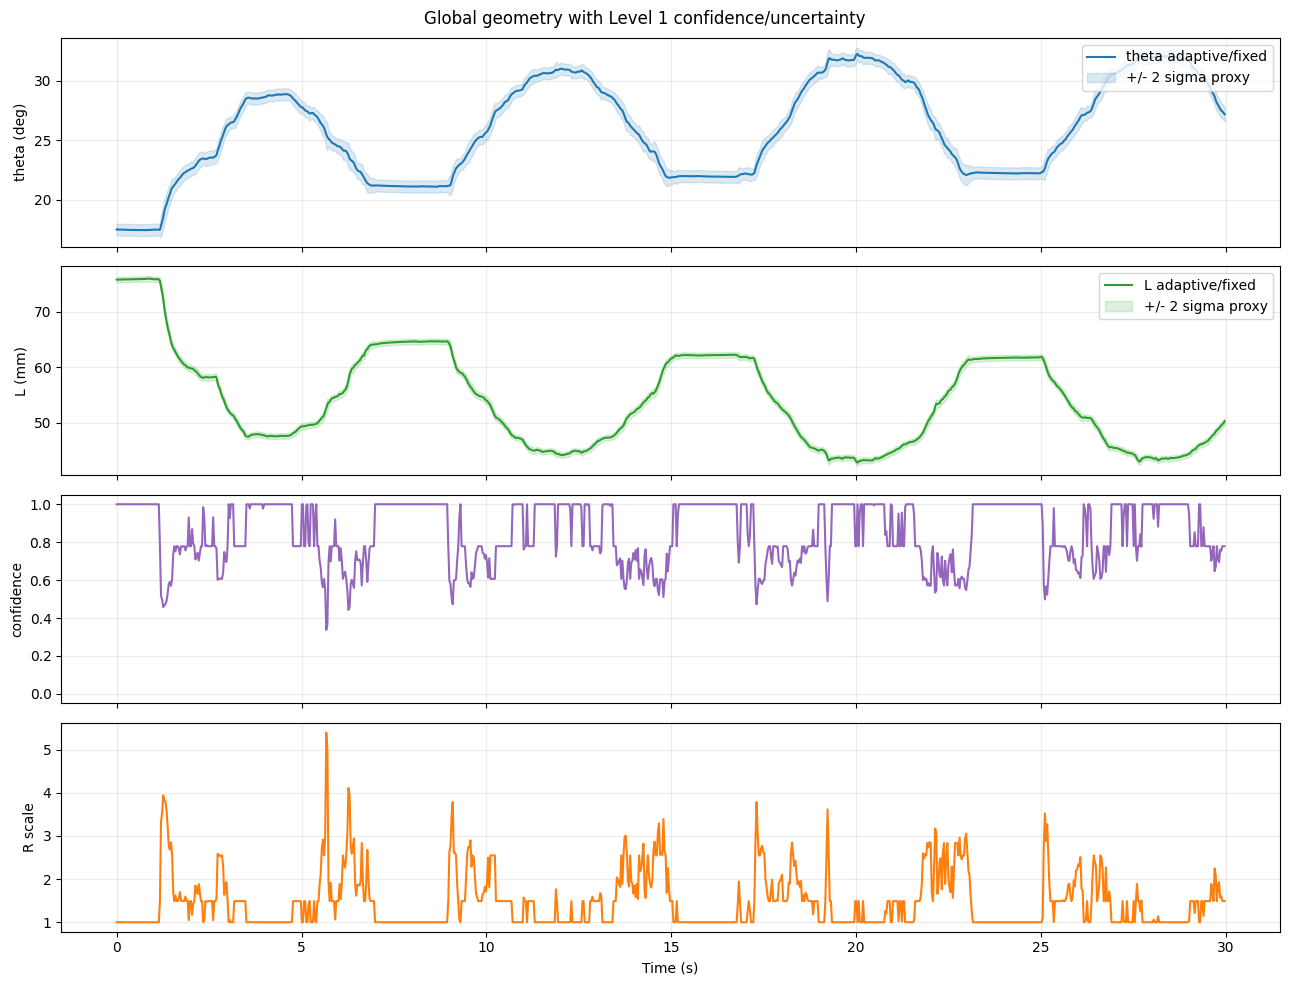

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
axes[0].plot(time_s, theta_deg, label='theta adaptive/fixed', color='tab:blue')
axes[0].fill_between(time_s, theta_deg - 2 * theta_sigma_deg, theta_deg + 2 * theta_sigma_deg, color='tab:blue', alpha=0.16, label='+/- 2 sigma proxy')
axes[0].set_ylabel('theta (deg)')
axes[0].legend(loc='upper right')

axes[1].plot(time_s, fl_mm, label='L adaptive/fixed', color='tab:green')
axes[1].fill_between(time_s, fl_mm - 2 * fl_sigma_mm, fl_mm + 2 * fl_sigma_mm, color='tab:green', alpha=0.16, label='+/- 2 sigma proxy')
axes[1].set_ylabel('L (mm)')
axes[1].legend(loc='upper right')

axes[2].plot(time_s, combined_confidence, color='tab:purple')
axes[2].set_ylabel('confidence')
axes[2].set_ylim(-0.05, 1.05)

axes[3].plot(time_s, R_scale, color='tab:orange')
axes[3].set_ylabel('R scale')
axes[3].set_xlabel('Time (s)')

for ax in axes:
    ax.grid(True, alpha=0.25)
fig.suptitle('Global geometry with Level 1 confidence/uncertainty')
fig.tight_layout()
path = OUT / 'theta_L_confidence_uncertainty_first30s.png'
fig.savefig(path, dpi=170)
path

## 9. Strain And Strain-Rate Time Series

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook60_local_speckle_mechanics_uncertainty/strain_and_strain_rate_first30s.png')

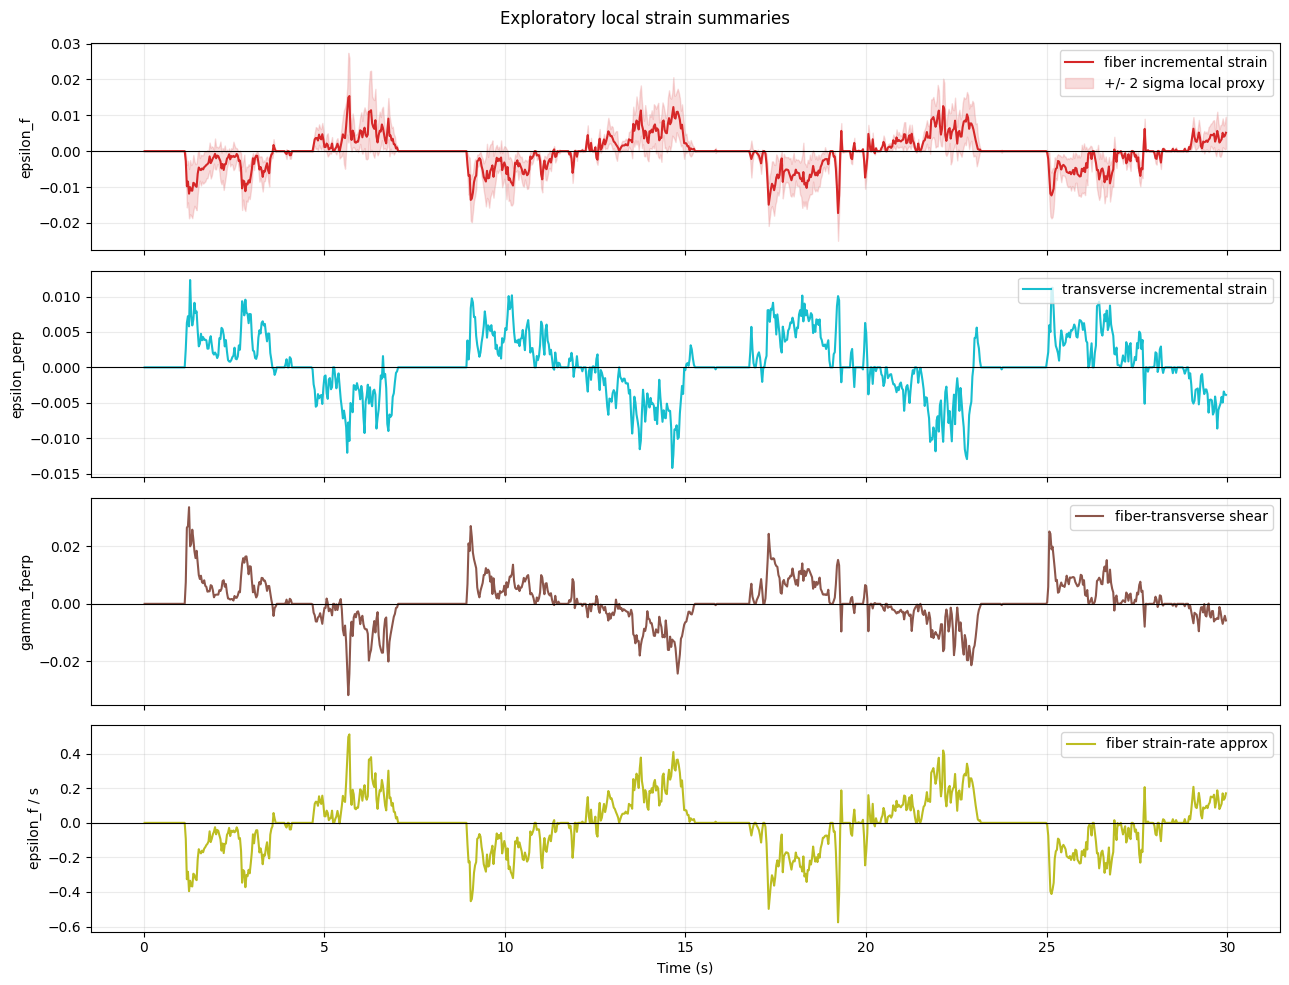

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
axes[0].plot(time_s, epsilon_f_median, label='fiber incremental strain', color='tab:red')
axes[0].fill_between(time_s, epsilon_f_median - 2 * epsilon_f_sigma_median, epsilon_f_median + 2 * epsilon_f_sigma_median, color='tab:red', alpha=0.16, label='+/- 2 sigma local proxy')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('epsilon_f')
axes[0].legend(loc='upper right')

axes[1].plot(time_s, epsilon_perp_median, label='transverse incremental strain', color='tab:cyan')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('epsilon_perp')
axes[1].legend(loc='upper right')

axes[2].plot(time_s, gamma_fperp_median, label='fiber-transverse shear', color='tab:brown')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('gamma_fperp')
axes[2].legend(loc='upper right')

axes[3].plot(time_s, strain_rate_f_median_s, label='fiber strain-rate approx', color='tab:olive')
axes[3].axhline(0, color='black', linewidth=0.8)
axes[3].set_ylabel('epsilon_f / s')
axes[3].set_xlabel('Time (s)')
axes[3].legend(loc='upper right')

for ax in axes:
    ax.grid(True, alpha=0.25)
fig.suptitle('Exploratory local strain summaries')
fig.tight_layout()
path = OUT / 'strain_and_strain_rate_first30s.png'
fig.savefig(path, dpi=170)
path

## 10. Confidence And Local Uncertainty Diagnostics

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook60_local_speckle_mechanics_uncertainty/confidence_uncertainty_diagnostics_first30s.png')

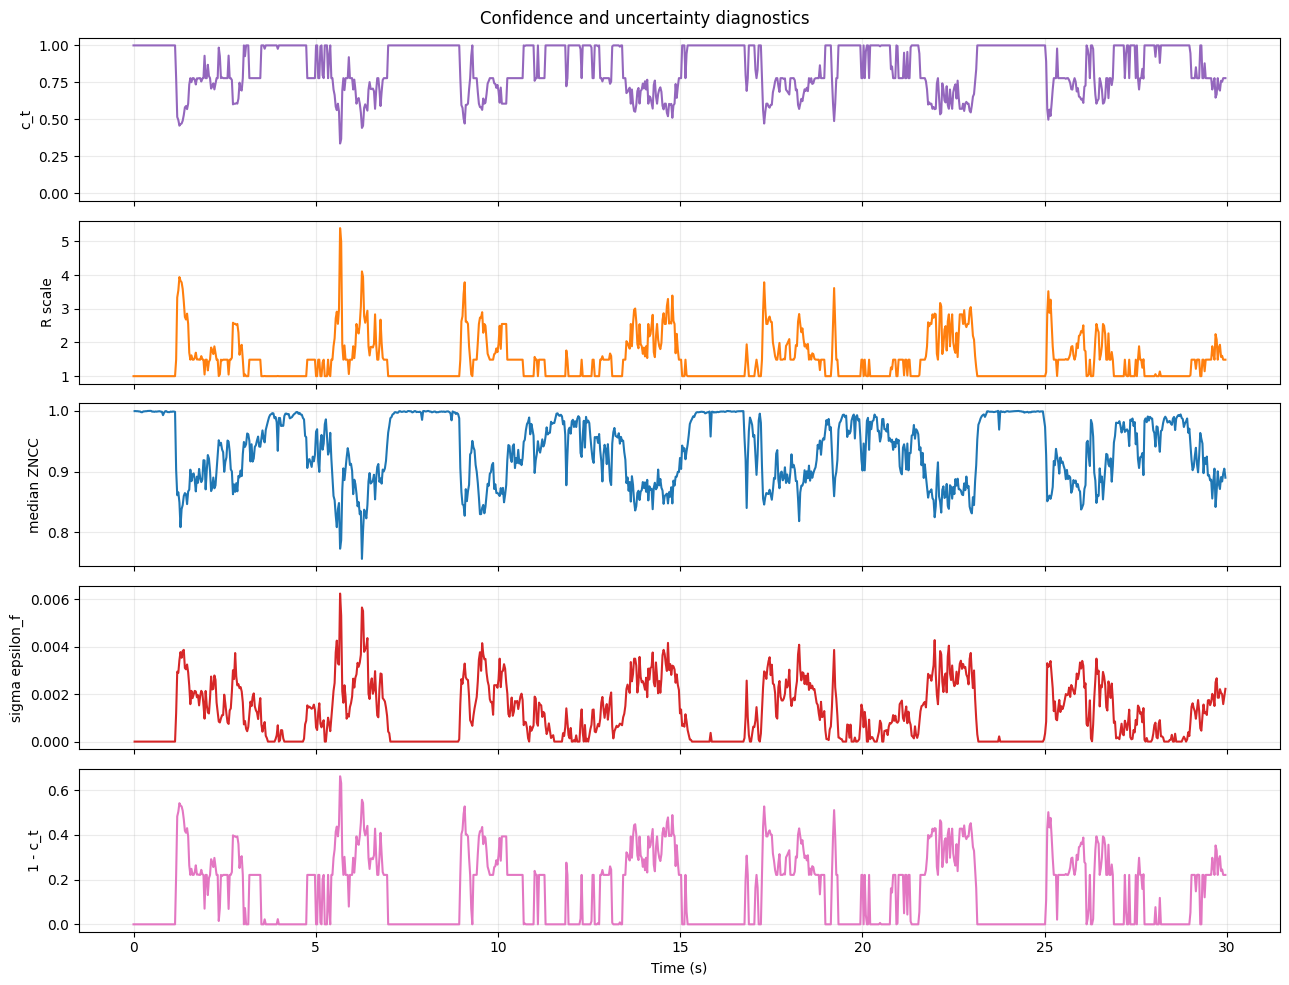

In [10]:
fig, axes = plt.subplots(5, 1, figsize=(13, 10), sharex=True)
axes[0].plot(time_s, combined_confidence, color='tab:purple')
axes[0].set_ylabel('c_t')
axes[0].set_ylim(-0.05, 1.05)
axes[1].plot(time_s, R_scale, color='tab:orange')
axes[1].set_ylabel('R scale')
axes[2].plot(time_s, np.asarray(conf_data['median_zncc'][:n_conf], dtype=float), color='tab:blue')
axes[2].set_ylabel('median ZNCC')
axes[3].plot(time_s, epsilon_f_sigma_median, color='tab:red')
axes[3].set_ylabel('sigma epsilon_f')
axes[4].plot(time_s, np.asarray(conf_data['out_of_plane_score'][:n_conf], dtype=float), color='tab:pink')
axes[4].set_ylabel('1 - c_t')
axes[4].set_xlabel('Time (s)')
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.suptitle('Confidence and uncertainty diagnostics')
fig.tight_layout()
path = OUT / 'confidence_uncertainty_diagnostics_first30s.png'
fig.savefig(path, dpi=170)
path

## 11. Example Frame: Displacement, Strain, And Uncertainty

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook60_local_speckle_mechanics_uncertainty/example_displacement_strain_uncertainty_overlay.png')

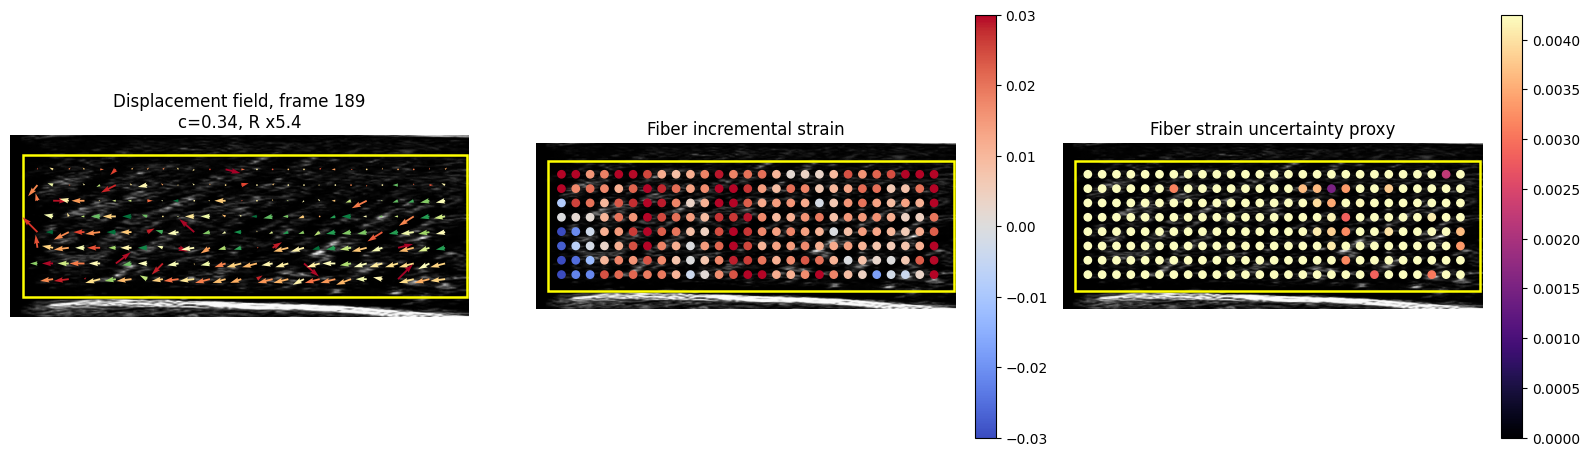

In [11]:
example_idx = int(np.nanargmax(R_scale)) if np.any(np.isfinite(R_scale)) else min(n_conf - 1, 1)
frames_for_overlay = read_gray_frames(VIDEO, limit=example_idx + 1)
frame = frames_for_overlay[example_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=True, sharey=True)
for ax in axes:
    ax.imshow(frame, cmap='gray')
    x, y, w, h = fascicle_roi
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor='yellow', linewidth=1.8))
    ax.set_xlim(max(0, x - 20), min(image_w, x + w + 20))
    ax.set_ylim(min(image_h, y + h + 30), max(0, y - 30))
    ax.set_axis_off()

valid = valid_mask[example_idx] & np.all(np.isfinite(displacements[example_idx]), axis=1)
disp = displacements[example_idx]
conf = local_confidence[example_idx]

axes[0].quiver(points[valid, 0], points[valid, 1], disp[valid, 0], disp[valid, 1], conf[valid], cmap='RdYlGn', angles='xy', scale_units='xy', scale=0.35, width=0.004)
axes[0].set_title(f'Displacement field, frame {example_idx}\nc={combined_confidence[example_idx]:.2f}, R x{R_scale[example_idx]:.1f}')

sc1 = axes[1].scatter(points[:, 0], points[:, 1], c=epsilon_f_map[example_idx], s=28, cmap='coolwarm', vmin=-0.03, vmax=0.03)
axes[1].set_title('Fiber incremental strain')
fig.colorbar(sc1, ax=axes[1], fraction=0.046, pad=0.04)

sc2 = axes[2].scatter(points[:, 0], points[:, 1], c=epsilon_f_sigma_map[example_idx], s=28, cmap='magma', vmin=0, vmax=np.nanpercentile(epsilon_f_sigma_map, 95))
axes[2].set_title('Fiber strain uncertainty proxy')
fig.colorbar(sc2, ax=axes[2], fraction=0.046, pad=0.04)

fig.tight_layout()
path = OUT / 'example_displacement_strain_uncertainty_overlay.png'
fig.savefig(path, dpi=180)
path

## 12. Compact Numerical Summary

In [12]:
summary = {
    'seconds_analyzed': float(time_s[-1]),
    'n_frames': int(n_conf),
    'n_sample_points': int(len(points)),
    'median_confidence': float(np.nanmedian(combined_confidence)),
    'min_confidence': float(np.nanmin(combined_confidence)),
    'max_R_scale': float(np.nanmax(R_scale)),
    'median_epsilon_f': float(np.nanmedian(epsilon_f_median)),
    'p01_p99_epsilon_f_map': (float(np.nanpercentile(epsilon_f_map, 1)), float(np.nanpercentile(epsilon_f_map, 99))),
    'median_epsilon_f_sigma': float(np.nanmedian(epsilon_f_sigma_median)),
    'median_fit_residual_px': float(np.nanmedian(fit_residual_median)),
}
summary_path = OUT / 'summary.json'
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')
summary

{'seconds_analyzed': 29.963108485048437,
 'n_frames': 1000,
 'n_sample_points': 216,
 'median_confidence': 0.8674571812152863,
 'min_confidence': 0.3373449146747589,
 'max_R_scale': 5.3911176210740255,
 'median_epsilon_f': 0.0,
 'p01_p99_epsilon_f_map': (-0.019012588262557983, 0.018641077615320675),
 'median_epsilon_f_sigma': 0.0008725309744477272,
 'median_fit_residual_px': 0.25208166241645813}

## Conclusion

This notebook demonstrates the Level 1 object requested in the PDF: `theta(t), L(t), u(x,y,t), strain(x,y,t), uncertainty(x,y,t)` for the first 30 seconds of the video.

Interpretation:

- high confidence means block-matched speckle patches remain coherent and local displacements agree with their neighbors;
- low confidence does not mean a frame must be discarded, but it means the geometry measurement should be trusted less;
- the strain maps are incremental image-plane strain estimates from sparse local affine fits;
- the uncertainty maps are Level 1 residual/confidence proxies, not final FEM posterior uncertainty;
- the next step is to move the stable parts into `ultrasound_tracker/speckle_confidence.py` or a new `local_mechanics.py` module, then add a true reduced-state or FEM prior only after these diagnostics are stable.